# LeetCode #519: Random Flip Matrix

https://leetcode.com/problems/random-flip-matrix/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (maintain all zeros)** | $O(m \cdot n)$ per flip | $O(m \cdot n)$ |
| **Optimal: Fisher-Yates via HashMap ★** | $O(1)$ per flip/reset | $O(\text{flips})$ |

---

## Understanding the Methods

### Brute Force (maintain all zeros)
Keep a list of all unflipped cell indices. For each flip, pick a random index from the list and remove it. Removal from an array is $O(n)$; list grows to $O(m \cdot n)$ space.

### Optimal: Fisher-Yates via HashMap ★
Treat the $m \times n$ matrix as a virtual 1-D array of size `total`. For each flip, pick a random index $r$ in $[0, \text{total})$, swap it with the last slot (using a HashMap to track swaps), and shrink `total`. Only flipped indices occupy the HashMap, so space is $O(\text{flips})$ and each operation is $O(1)$.

**Why this is better than Brute Force:** The HashMap-based virtual swap avoids materializing the full cell list — space scales with the number of flips, not the matrix size.

**Constraints:**
* $1 \le m, n \le 10^4$
* At most $m \times n$ calls to `flip`
* At most $10^3$ calls to `reset`


## Solutions

### C#

In [ ]:
public class Solution {
    int m, n, total;
    Random rng = new Random();
    Dictionary<int,int> map = new Dictionary<int,int>();
    public Solution(int m, int n) { this.m=m; this.n=n; total=m*n; }
    public int[] Flip() {
        // Pick a random index from the remaining unflipped slots
        int r = rng.Next(total--);
        // Retrieve the real cell index (may have been swapped)
        int x = map.TryGetValue(r, out int v) ? v : r;
        // Swap slot r with the last unflipped slot via HashMap
        map[r] = map.TryGetValue(total, out int t) ? t : total;
        return new int[]{ x/n, x%n };
    }
    public void Reset() { map.Clear(); total=m*n; }
}

### Python

In [ ]:
import random

class Solution:
    def __init__(self, m: int, n: int):
        self.m, self.n = m, n
        self.total = m * n
        self.map: dict[int, int] = {}

    def flip(self) -> list[int]:
        # Pick a random index from the remaining unflipped slots
        r = random.randint(0, self.total - 1)
        self.total -= 1
        # Retrieve the real cell index (may have been swapped)
        x = self.map.get(r, r)
        # Swap slot r with the last unflipped slot via HashMap
        self.map[r] = self.map.get(self.total, self.total)
        return [x // self.n, x % self.n]

    def reset(self) -> None:
        self.map.clear()
        self.total = self.m * self.n

### Go

In [ ]:
import "math/rand"

type Solution struct {
    m, n, total int
    mp          map[int]int
}

func Constructor(m int, n int) Solution {
    return Solution{m: m, n: n, total: m * n, mp: make(map[int]int)}
}

func (s *Solution) Flip() []int {
    // Pick a random index from the remaining unflipped slots
    r := rand.Intn(s.total)
    s.total--
    // Retrieve the real cell index (may have been swapped)
    x, ok := s.mp[r]
    if !ok { x = r }
    // Swap slot r with the last unflipped slot via HashMap
    t, ok2 := s.mp[s.total]
    if !ok2 { t = s.total }
    s.mp[r] = t
    return []int{x / s.n, x % s.n}
}

func (s *Solution) Reset() {
    s.mp = make(map[int]int)
    s.total = s.m * s.n
}

### Rust

In [ ]:
use std::collections::HashMap;
use rand::Rng;

struct Solution {
    m: i32, n: i32, total: i32,
    map: HashMap<i32, i32>,
}

impl Solution {
    fn new(m: i32, n: i32) -> Self {
        Solution { m, n, total: m * n, map: HashMap::new() }
    }

    fn flip(&mut self) -> Vec<i32> {
        // Pick a random index from the remaining unflipped slots
        let r = rand::thread_rng().gen_range(0..self.total);
        self.total -= 1;
        // Retrieve the real cell index (may have been swapped)
        let x = *self.map.get(&r).unwrap_or(&r);
        // Swap slot r with the last unflipped slot via HashMap
        let t = *self.map.get(&self.total).unwrap_or(&self.total);
        self.map.insert(r, t);
        vec![x / self.n, x % self.n]
    }

    fn reset(&mut self) {
        self.map.clear();
        self.total = self.m * self.n;
    }
}

## Example Scenarios

**1. Common Case**
**Input:** `m=2, n=3`; call `flip()` twice
Total=6. First flip: random $r=4$, $x=4$, map[4]=5, total=5. Row=4/3=1, col=4%3=1 → [1,1]. Second: random $r=2$, $x=2$, map[2]=4, total=4 → [0,2]. Two distinct cells returned.

**2. Slightly Complex**
**Input:** `m=1, n=4`; flip all 4 cells then reset and flip again
After 4 flips the HashMap holds up to 4 entries. Reset clears the map and restores total=4. The next flip sequence is uniformly random again — no bias from previous flips.

**3. Edge Case: Time Factor**
**Input:** `m=10^4, n=10^4` ($10^8$ cells); flip $10^8$ times
Each flip is $O(1)$ — just a random number, two HashMap lookups, and one insert. No array copying. Total: $O(m \cdot n)$ flips all run in $O(1)$ each.

**4. Edge Case: Space Factor**
**Input:** `m=10^4, n=10^4`; flip $10^3$ times (problem limit)
Only $10^3$ flips are allowed, so the HashMap holds at most $10^3$ entries — $O(\text{flips})$ space, far less than the $O(m \cdot n) = 10^8$ brute-force array.

**5. Almost-Impossible but Plausible**
**Input:** `m=1, n=1`; flip then reset then flip again
Total=1. First flip: $r=0$, $x=0$, return [0,0]. total=0. Reset: total=1, map cleared. Second flip again returns [0,0]. The single cell is always returned after reset.


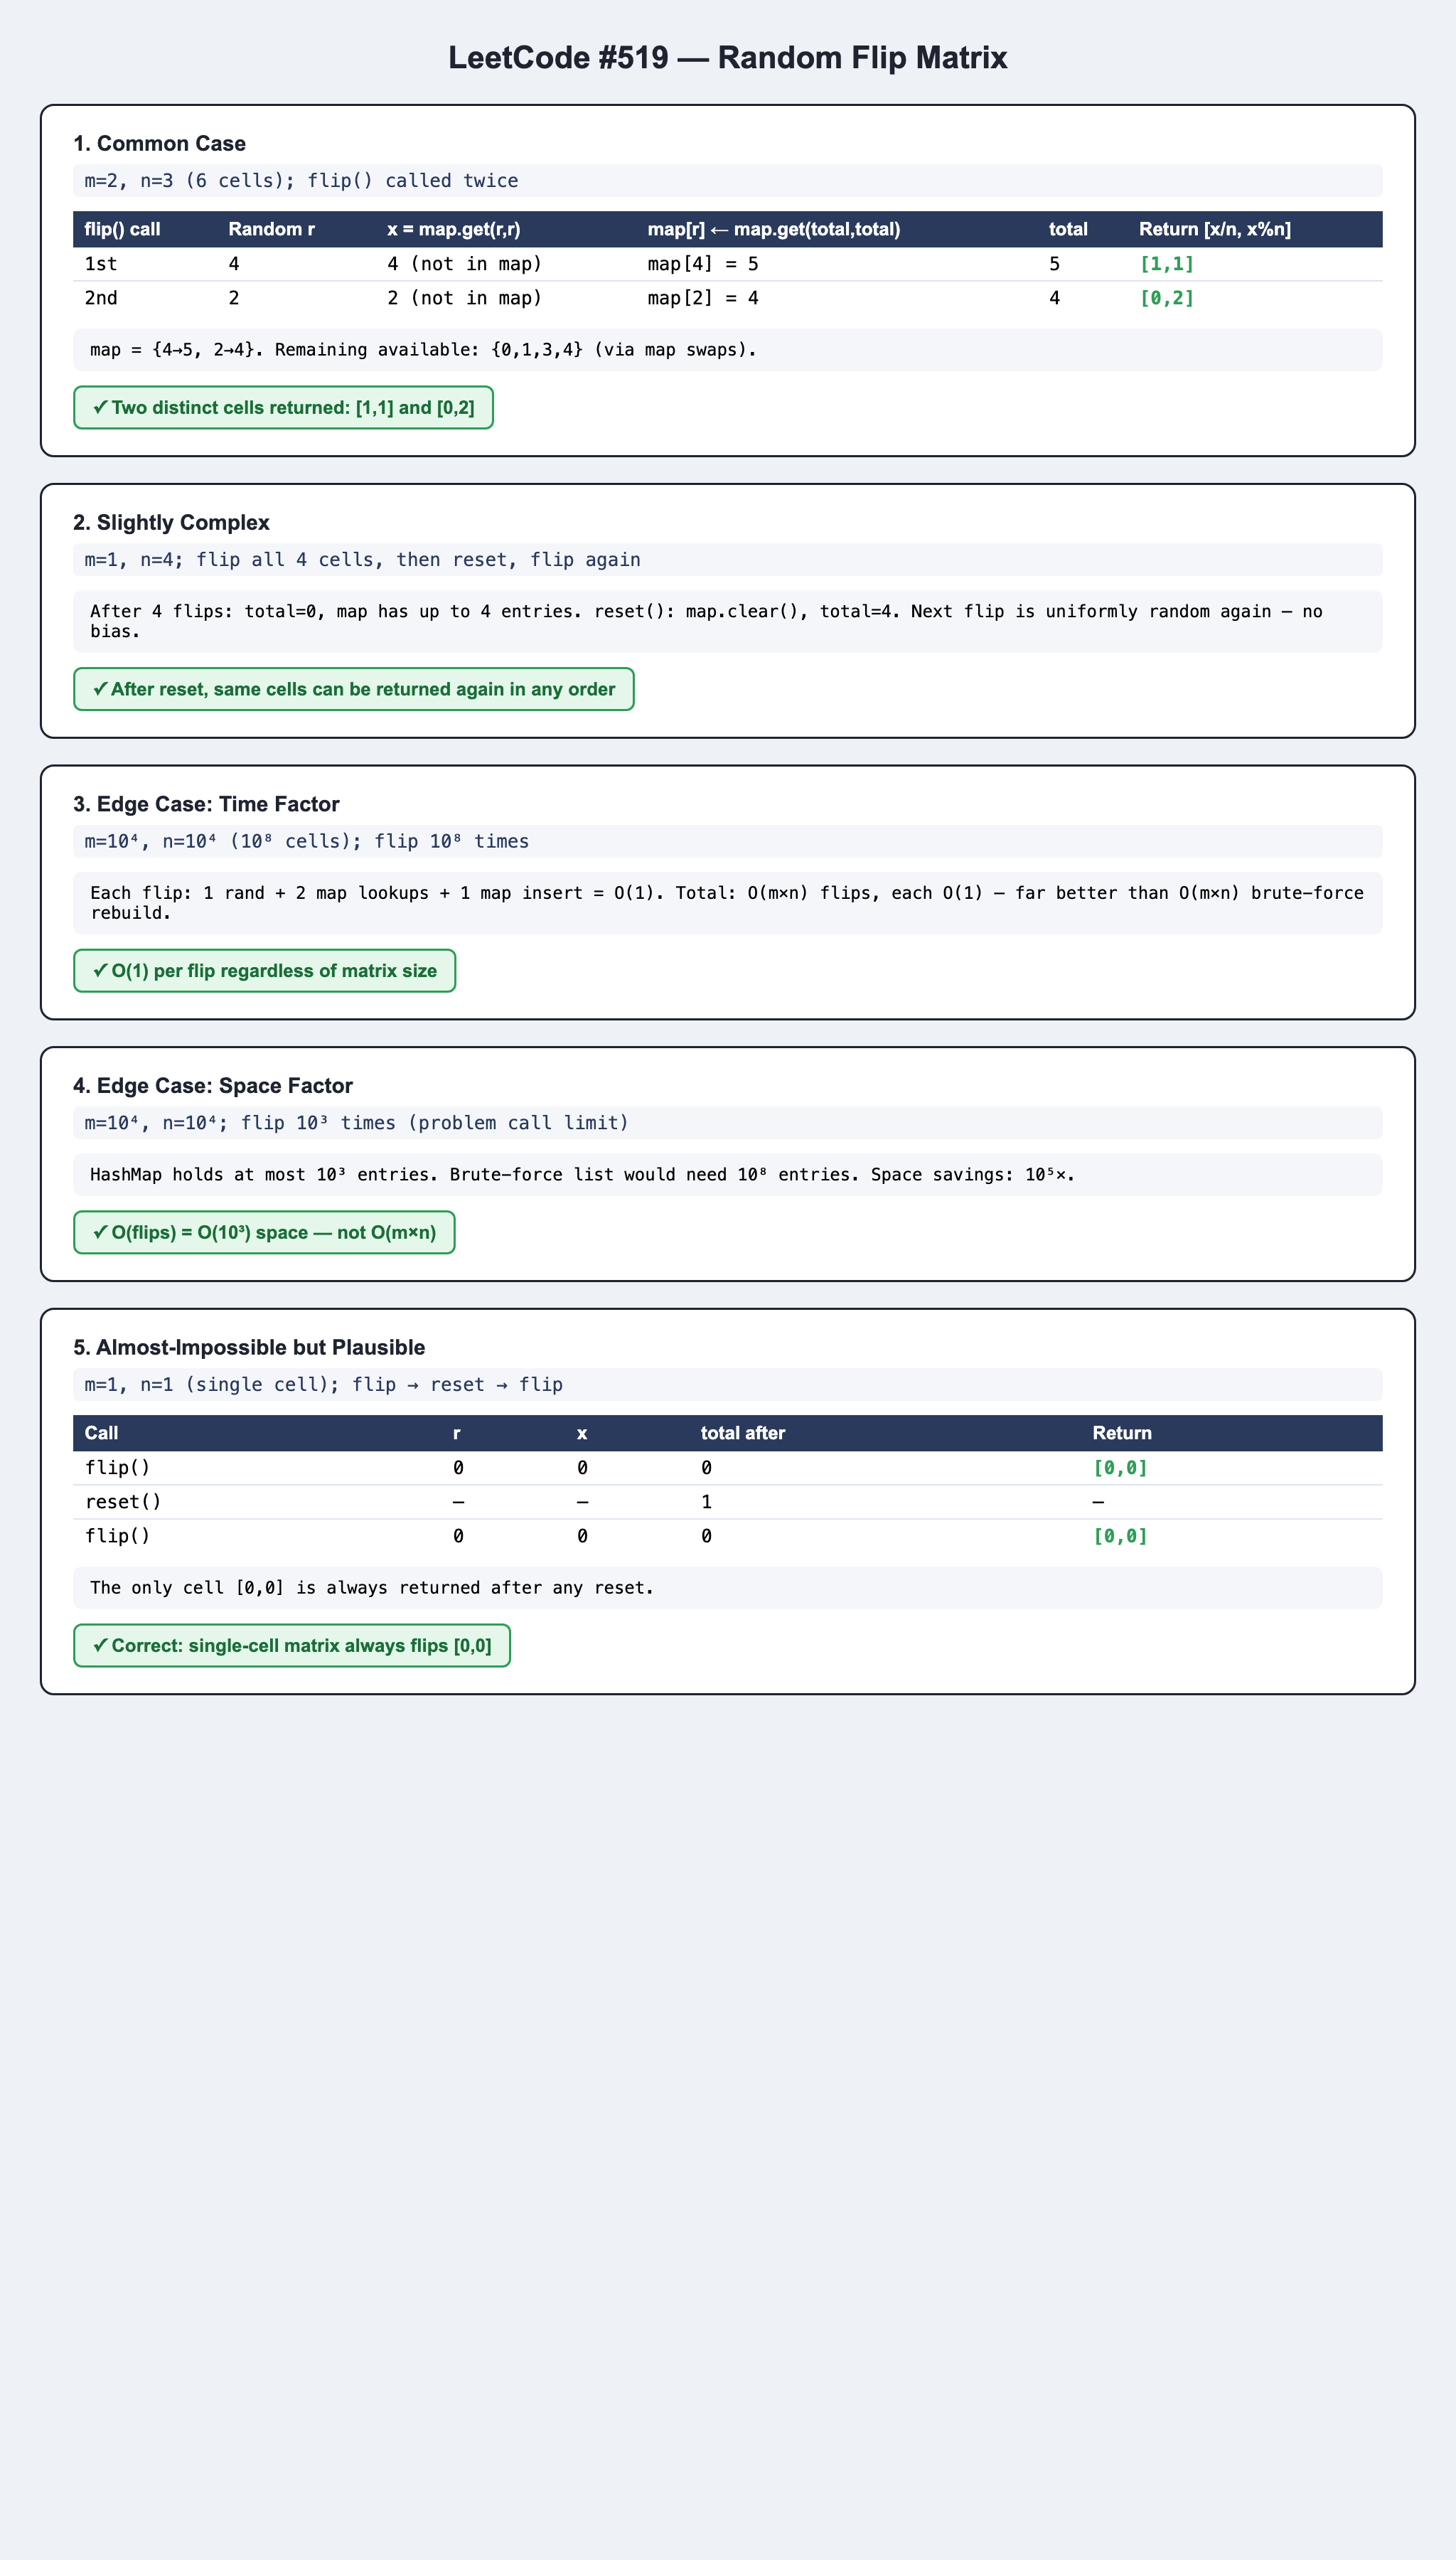